# Lab 09 — Calidad del Dato y Preparación del Dataset
### Microcredencial en Ciencia de Datos

En este lab trabajaremos con el dataset **Melbourne Housing** para practicar:

1. Diagnóstico de valores faltantes
2. Estrategias de imputación: simple, por grupo y KNN
3. Indicadores de missingness
4. Detección y tratamiento de outliers con IQR
5. Decisión de representación: numérica vs categórica
6. Train/Test split sin data leakage

---

**Dataset**: `Melbourne_housing_FULL.csv` en la carpeta `data/`  
**Fuente**: [Kaggle - Melbourne Housing Market](https://www.kaggle.com/datasets/anthonypino/melbourne-housing-market)

In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   -------------------- ------------------- 4.5/8.9 MB 24.5 MB/s eta 0:00:01
   ---------------------------------------- 8.9/8.9 MB 26.3 MB/s  0:00:00
   ---------------------------------------- 0.0/41.3 MB ? eta -:--:--
   ------- -------------------------------- 7.3/41.3 MB 37.6 MB/s eta 0:00:01
   --------------- ------------------------ 16.0/41.3 MB 38.7 MB/s eta 0:00:01
   ----------------------- ---------------- 24.4/41.3 MB 38.6 MB/s eta 0:00:01
   -------------------------- ------------- 27.5/41.3 MB 35.6 MB/s eta 0:00:01
   --------------------------------- ------ 34.9/41.3 MB 32.6 MB/s eta 0:00:01
   ---------------------------------------  41.2/41.3 MB 34.0 MB/s eta 0:00:01
   ---------------------------------------- 41.3/41.3 MB 32.0 MB/s  0:00:01

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 

In [5]:
# ─── SETUP: librerías y carga del dataset ─────────────────────────────────────
# Cargamos las librerías principales:
# - pandas/numpy: manipulación de datos
# - matplotlib/seaborn: visualización
# - SimpleImputer: imputación de valores faltantes con estrategias básicas (media, mediana)
# - KNNImputer: imputación usando los K vecinos más similares
# - train_test_split: dividir los datos en train/test sin contaminar

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', 30)
sns.set_style('whitegrid')

DATA_PATH = Path('data')
df = pd.read_csv(DATA_PATH / 'Melbourne_housing_FULL.csv')

print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')
df.head()

Dataset cargado: 34,857 filas x 21 columnas


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,2.0,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,2.0,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,3.0,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0


---
## Parte 1 — Diagnóstico de calidad de datos

In [6]:
# ─── Tipos de variables y estadísticas descriptivas ───────────────────────────
# .dtypes muestra el tipo de cada columna (int64, float64, object...).
# Las columnas float64 con muchos NaN indican variables con faltantes.
# .describe() da media, desviación típica, mín, máx y cuartiles — permite
# detectar valores sospechosos (ej: YearBuilt = 1196 o Landsize = 433.014).

print('=== TIPOS DE VARIABLES ===')
print(df.dtypes)
print()
print('=== ESTADÍSTICAS DESCRIPTIVAS ===')
df.describe()

=== TIPOS DE VARIABLES ===
Suburb            object
Address           object
Rooms              int64
Type              object
Price            float64
Method            object
SellerG           object
Date              object
Distance         float64
Postcode         float64
Bedroom2         float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea     float64
YearBuilt        float64
CouncilArea       object
Lattitude        float64
Longtitude       float64
Regionname        object
Propertycount    float64
dtype: object

=== ESTADÍSTICAS DESCRIPTIVAS ===


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,34857.000000,2.724700e+04,34856.000000,34856.000000,26640.000000,26631.000000,26129.000000,23047.000000,13742.00000,15551.000000,26881.000000,26881.000000,34854.000000
mean,3.031012,1.050173e+06,11.184929,3116.062859,3.084647,1.624798,1.728845,593.598993,160.25640,1965.289885,-37.810634,145.001851,7572.888306
std,0.969933,6.414671e+05,6.788892,109.023903,0.980690,0.724212,1.010771,3398.841946,401.26706,37.328178,0.090279,0.120169,4428.090313
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1196.000000,-38.190430,144.423790,83.000000
25%,2.000000,6.350000e+05,6.400000,3051.000000,2.000000,1.000000,1.000000,224.000000,102.00000,1940.000000,-37.862950,144.933500,4385.000000
50%,3.000000,8.700000e+05,10.300000,3103.000000,3.000000,2.000000,2.000000,521.000000,136.00000,1970.000000,-37.807600,145.007800,6763.000000
75%,4.000000,1.295000e+06,14.000000,3156.000000,4.000000,2.000000,2.000000,670.000000,188.00000,2000.000000,-37.754100,145.071900,10412.000000
max,16.000000,1.120000e+07,48.100000,3978.000000,30.000000,12.000000,26.000000,433014.000000,44515.00000,2106.000000,-37.390200,145.526350,21650.000000


Puede pitar el CP _> float
df.describe() importante -> estádisticas básicas


In [ ]:
df.shape

In [8]:
# ─── Diagnóstico de valores faltantes ─────────────────────────────────────────
# Contamos cuántos NaN tiene cada columna y calculamos su porcentaje.
# Ordenamos de mayor a menor para ver rápidamente cuáles son las más afectadas.
# Variables con >50% de faltantes (como BuildingArea) requieren decisiones cuidadosas:
# ¿imputar, eliminar la columna, o crear un indicador de missingness?

missing = pd.DataFrame({
    'faltantes': df.isnull().sum(),
    'porcentaje': (df.isnull().sum()/df.shape[0] * 100).round(1)
}).sort_values('porcentaje', ascending=False)

print('=== VALORES FALTANTES POR COLUMNA ===')
print(missing[missing['faltantes'] > 0].to_string())

=== VALORES FALTANTES POR COLUMNA ===
               faltantes  porcentaje
BuildingArea       21115        60.6
YearBuilt          19306        55.4
Landsize           11810        33.9
Car                 8728        25.0
Bathroom            8226        23.6
Bedroom2            8217        23.6
Lattitude           7976        22.9
Longtitude          7976        22.9
Price               7610        21.8
Postcode               1         0.0
Distance               1         0.0
CouncilArea            3         0.0
Regionname             3         0.0
Propertycount          3         0.0


Porcentaje valores ausentes

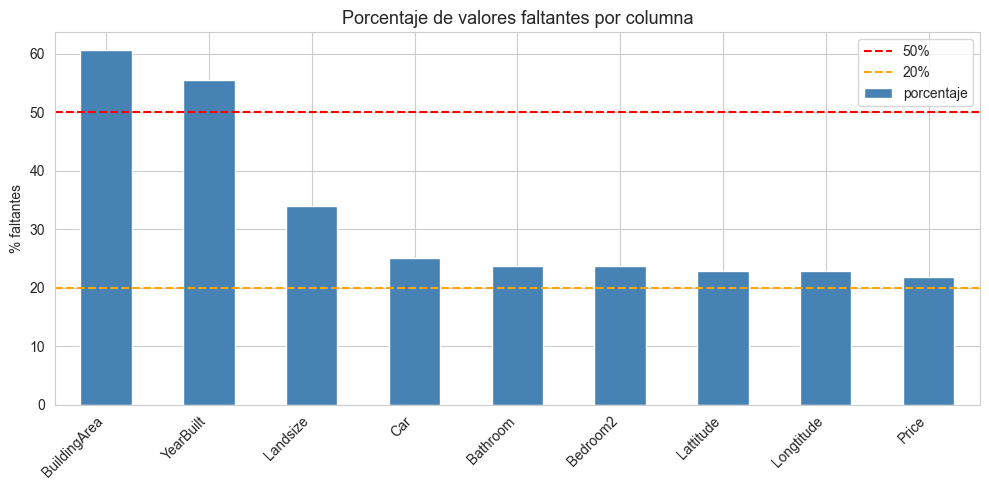

In [9]:
# ─── Visualización del porcentaje de faltantes ────────────────────────────────
# Un gráfico de barras permite ver de un vistazo qué variables están más afectadas.
# Las líneas de referencia al 50% y 20% ayudan a clasificar la gravedad:
# - >50%: considerar eliminar la columna o crear un indicador binario
# - 20-50%: imputación necesaria, elegir estrategia con cuidado
# - <5%: imputación simple suele ser suficiente

plt.figure(figsize=(10, 5))
datos_plot = missing[missing['porcentaje'] > 0]['porcentaje']
datos_plot.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Porcentaje de valores faltantes por columna', fontsize=13)
plt.ylabel('% faltantes')
plt.xticks(rotation=45, ha='right')
plt.axhline(50, color='red', linestyle='--', label='50%')
plt.axhline(20, color='orange', linestyle='--', label='20%')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# ─── Investigar si los faltantes siguen un patrón (MAR vs MCAR) ───────────────
# Hipótesis: ¿los pisos (Type=u) tienen más faltantes en BuildingArea que las casas (Type=h)?
# Si el % de faltantes varía según el tipo de propiedad, los datos son MAR
# (Missing At Random): el faltante depende de otra variable observable.
# Si fuera MCAR (Missing Completely At Random), el % sería igual en todos los grupos.

print('% de BuildingArea faltante por tipo de propiedad:')
pct_ba = df.groupby('Type')['BuildingArea'].apply(lambda x: round(x.isnull().mean() * 100, 1))
print(pct_ba.rename('% missing'))

print()
print('% de YearBuilt faltante por tipo de propiedad:')
pct_yb = df.groupby('Type')['YearBuilt'].apply(lambda x: round(x.isnull().mean() * 100, 1))
print(pct_yb.rename('% missing'))

% de BuildingArea faltante por tipo de propiedad:
Type
h    56.6
t    68.4
u    69.9
Name: % missing, dtype: float64

% de YearBuilt faltante por tipo de propiedad:
Type
h    52.2
t    64.4
u    61.3
Name: % missing, dtype: float64


**Reflexión MAR**: Si el % de faltantes varía según `Type`, los datos son **MAR** (Missing At Random): el faltante no es aleatorio puro, sino que depende de otra variable observable.  
En ese caso, la **imputación por grupo** (mediana por `Type`) es más adecuada que la mediana global.

---
## Parte 2 — Estrategias de imputación

### 2.1 — Imputación simple: mediana global

In [11]:
# ─── Imputación simple: reemplazar faltantes con la mediana global ─────────────
# La mediana es más robusta que la media ante outliers (ej: Landsize = 433.014 m²).
# Usamos .fillna(mediana) para cada columna numérica con faltantes.
#
# Limitación: la mediana global ignora que distintos tipos de propiedad (h, t, u)
# pueden tener superficies muy diferentes. Todos reciben el mismo valor imputado.

cols_num_missing = ['BuildingArea', 'YearBuilt', 'Landsize', 'Car', 'Bathroom', 'Bedroom2']

df_simple = df.copy()

medianas_globales = {}
for col in cols_num_missing:
    med = df_simple[col].median()
    medianas_globales[col] = med
    df_simple[col] = df_simple[col].fillna(med)

print('Faltantes despues de imputacion simple:')
print(df_simple[cols_num_missing].isnull().sum())
print()
print('Medianas usadas:')
for col, med in medianas_globales.items():
    print(f'  {col}: {med:.1f}')

Faltantes despues de imputacion simple:
BuildingArea    0
YearBuilt       0
Landsize        0
Car             0
Bathroom        0
Bedroom2        0
dtype: int64

Medianas usadas:
  BuildingArea: 136.0
  YearBuilt: 1970.0
  Landsize: 521.0
  Car: 2.0
  Bathroom: 2.0
  Bedroom2: 3.0


### 2.2 — Imputación por grupo: mediana por tipo de propiedad

Como vimos que el faltante es MAR respecto a `Type`, imputamos con la mediana de cada grupo.

In [12]:
df_grupo = df.copy()

for col in ['BuildingArea', 'YearBuilt']:
    # Mediana por tipo de propiedad
    df_grupo[col] = df_grupo.groupby('Type')[col].transform(
        lambda x: x.fillna(x.median())
    )
    # Si quedan faltantes (grupos sin datos suficientes), mediana global
    df_grupo[col] = df_grupo[col].fillna(df_grupo[col].median())

# Para el resto, mediana simple
for col in ['Landsize', 'Car', 'Bathroom', 'Bedroom2']:
    df_grupo[col] = df_grupo[col].fillna(df_grupo[col].median())

print('Faltantes despues de imputacion por grupo:')
print(df_grupo[cols_num_missing].isnull().sum())

Faltantes despues de imputacion por grupo:
BuildingArea    0
YearBuilt       0
Landsize        0
Car             0
Bathroom        0
Bedroom2        0
dtype: int64


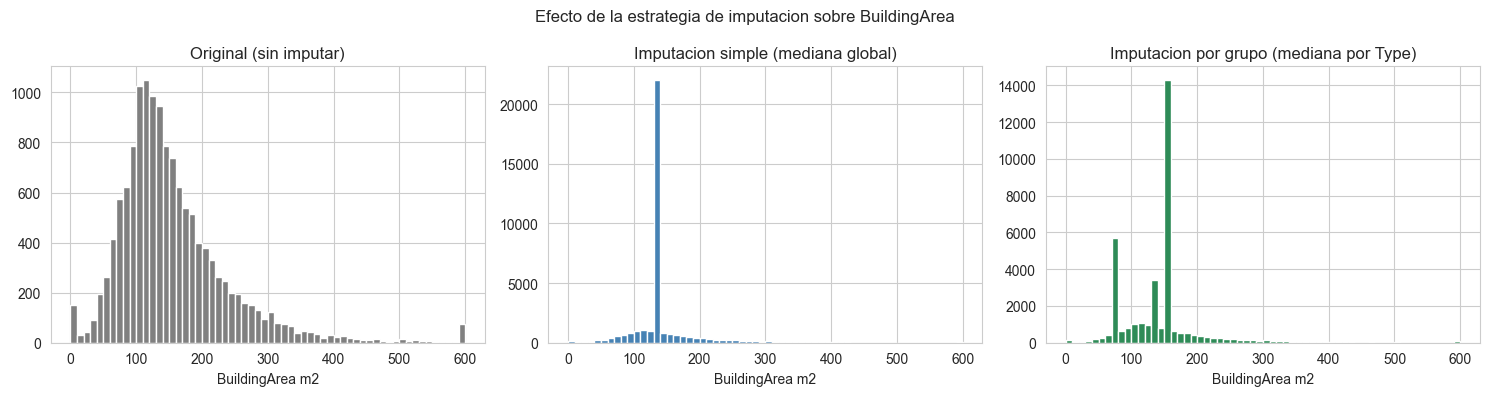

Desviacion tipica BuildingArea:
  Original (solo no-missing):  401.3
  Imputacion simple:           252.2
  Imputacion por grupo:        253.6

La imputacion simple crea un pico artificial en la mediana global.
La imputacion por grupo distribuye mejor los valores imputados.


In [13]:
# Comparar distribuciones de BuildingArea despues de cada estrategia
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

df['BuildingArea'].dropna().clip(0, 600).hist(
    bins=60, ax=axes[0], color='gray', edgecolor='white')
axes[0].set_title('Original (sin imputar)')
axes[0].set_xlabel('BuildingArea m2')

df_simple['BuildingArea'].clip(0, 600).hist(
    bins=60, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Imputacion simple (mediana global)')
axes[1].set_xlabel('BuildingArea m2')

df_grupo['BuildingArea'].clip(0, 600).hist(
    bins=60, ax=axes[2], color='seagreen', edgecolor='white')
axes[2].set_title('Imputacion por grupo (mediana por Type)')
axes[2].set_xlabel('BuildingArea m2')

plt.suptitle('Efecto de la estrategia de imputacion sobre BuildingArea', fontsize=12)
plt.tight_layout()
plt.show()

std_orig   = df['BuildingArea'].std()
std_simple = df_simple['BuildingArea'].std()
std_grupo  = df_grupo['BuildingArea'].std()
print(f'Desviacion tipica BuildingArea:')
print(f'  Original (solo no-missing):  {std_orig:.1f}')
print(f'  Imputacion simple:           {std_simple:.1f}')
print(f'  Imputacion por grupo:        {std_grupo:.1f}')
print()
print('La imputacion simple crea un pico artificial en la mediana global.')
print('La imputacion por grupo distribuye mejor los valores imputados.')

Muchos picos poeque faltaban muchos valores... no es la panacea

### 2.3 — KNN Imputer: dejar que el algoritmo decida

In [14]:
# KNN Imputer usa los k vecinos mas similares para imputar
# Solo funciona con variables numericas

cols_para_knn = ['Rooms', 'Distance', 'Bedroom2', 'Bathroom', 'Car',
                 'Landsize', 'BuildingArea', 'YearBuilt', 'Propertycount']

df_knn_input = df[cols_para_knn].copy()

knn_imputer = KNNImputer(n_neighbors=5)
df_knn_imputed = pd.DataFrame(
    knn_imputer.fit_transform(df_knn_input),
    columns=cols_para_knn
)

print('Faltantes despues de KNN Imputer:')
print(df_knn_imputed.isnull().sum())

mean_simple = df_simple['BuildingArea'].mean()
mean_knn    = df_knn_imputed['BuildingArea'].mean()
std_simple  = df_simple['BuildingArea'].std()
std_knn     = df_knn_imputed['BuildingArea'].std()

print()
print('Comparacion de BuildingArea imputada:')
print(f'  Media simple:   {mean_simple:.1f}   |  Media KNN: {mean_knn:.1f}')
print(f'  Std simple:     {std_simple:.1f}   |  Std KNN:   {std_knn:.1f}')

Faltantes despues de KNN Imputer:
Rooms            0
Distance         0
Bedroom2         0
Bathroom         0
Car              0
Landsize         0
BuildingArea     0
YearBuilt        0
Propertycount    0
dtype: int64

Comparacion de BuildingArea imputada:
  Media simple:   145.6   |  Media KNN: 152.7
  Std simple:     252.2   |  Std KNN:   267.6


### 2.4 — Indicador de missingness para Price (MNAR)

`Price` tiene un 21.8% de faltantes. En el mercado inmobiliario, el precio **no se divulga** cuando la venta fue discreta.  
El faltante depende del propio valor → **MNAR** (Missing Not At Random).

No podemos imputarlo de forma fiable, pero podemos crear un **indicador binario** que el modelo use como feature.

In [ ]:
# Crear indicador de missingness
df_grupo['price_missing'] = df['Price'].isnull().astype(int)

print('Distribucion del indicador:')
print(df_grupo['price_missing'].value_counts())

# Los que no tienen precio, son propiedades distintas?
print()
print('Tipo de propiedad segun si tiene precio registrado:')
print(
    df_grupo.groupby('price_missing')['Type']
      .value_counts(normalize=True)
      .mul(100).round(1)
      .rename('% dentro del grupo')
)

print()
print('Rooms medio segun si tiene precio:')
print(df_grupo.groupby('price_missing')['Rooms'].mean().round(2))

---
## Parte 3 — Detección y tratamiento de outliers

### 3.1 — Visualización exploratoria con boxplots

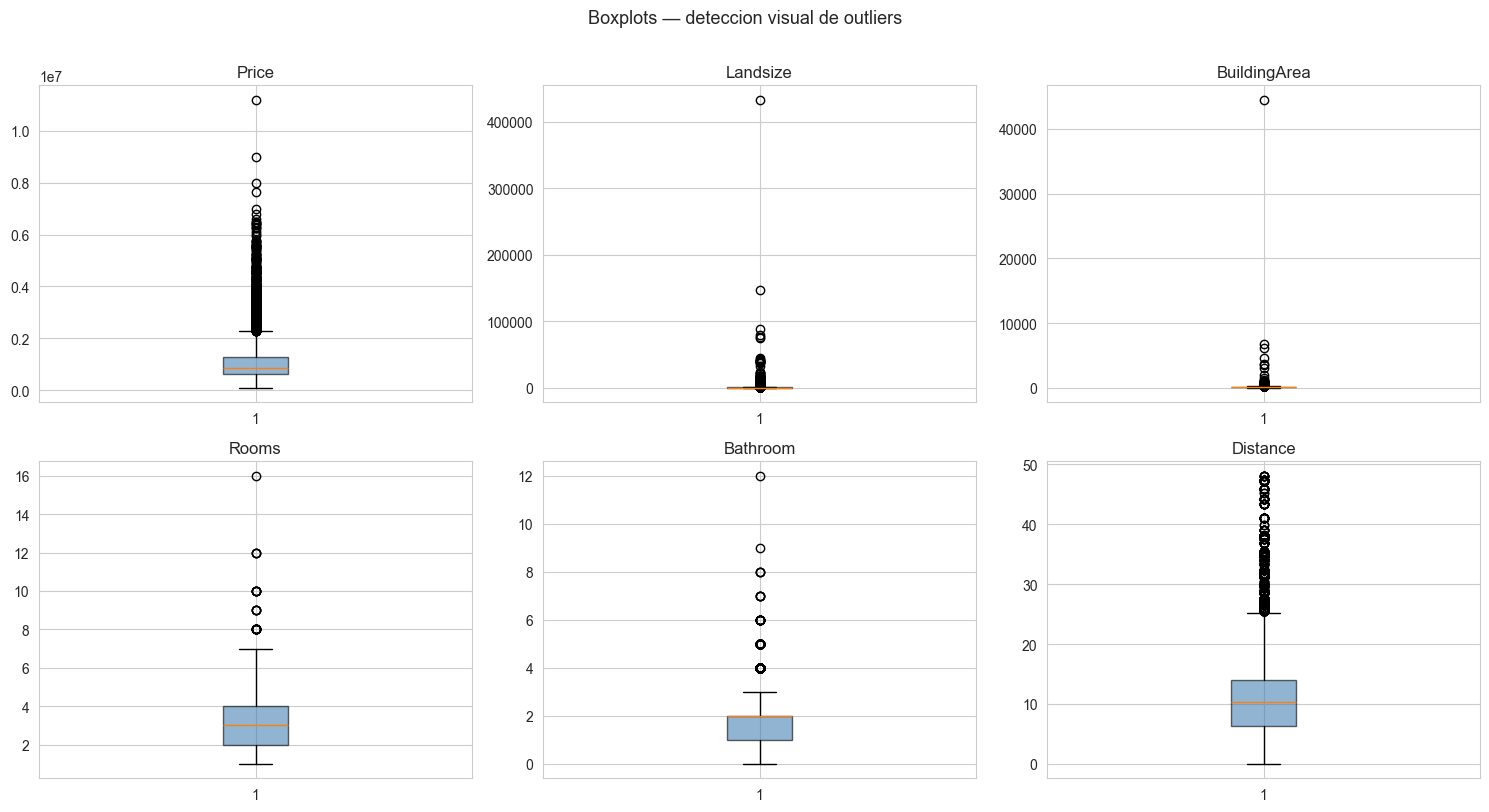

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols_viz = ['Price', 'Landsize', 'BuildingArea', 'Rooms', 'Bathroom', 'Distance']

for i, col in enumerate(cols_viz):
    ax = axes[i // 3, i % 3]
    data = df[col].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col)

plt.suptitle('Boxplots — deteccion visual de outliers', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 3.2 — Detección con IQR

In [16]:
def detectar_outliers_iqr(serie, factor=1.5):
    """Devuelve mascara booleana True para outliers y los limites."""
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - factor * IQR
    limite_sup = Q3 + factor * IQR
    mask = (serie < limite_inf) | (serie > limite_sup)
    return mask, limite_inf, limite_sup


for col in ['Price', 'Landsize', 'BuildingArea']:
    serie = df[col].dropna()
    mask, li, ls = detectar_outliers_iqr(serie)
    n_out = mask.sum()
    pct   = mask.mean() * 100
    print(f'{col}:')
    print(f'  Limites IQR: [{li:,.0f} , {ls:,.0f}]')
    print(f'  Outliers: {n_out:,} ({pct:.1f}%)')
    print(f'  Valor maximo: {serie.max():,.0f}')
    print()

Price:
  Limites IQR: [-355,000 , 2,285,000]
  Outliers: 1,278 (4.7%)
  Valor maximo: 11,200,000

Landsize:
  Limites IQR: [-445 , 1,339]
  Outliers: 594 (2.6%)
  Valor maximo: 433,014

BuildingArea:
  Limites IQR: [-27 , 317]
  Outliers: 624 (4.5%)
  Valor maximo: 44,515



In [17]:
# Analizar outliers de Price: son errores o casos validos?
df_price_valid = df[['Price', 'Rooms', 'Type', 'Suburb', 'Distance']].dropna(subset=['Price'])
mask_price, li_price, ls_price = detectar_outliers_iqr(df_price_valid['Price'])
df_price_valid = df_price_valid.copy()
df_price_valid['es_outlier'] = mask_price.values

print('Top 10 propiedades mas caras (outliers superiores):')
print(
    df_price_valid[df_price_valid['es_outlier']]
      .sort_values('Price', ascending=False)
      .head(10)
      .to_string(index=False)
)

print()
print('Tipo de propiedad entre outliers de precio:')
print(df_price_valid[df_price_valid['es_outlier']]['Type'].value_counts())

Top 10 propiedades mas caras (outliers superiores):
     Price  Rooms Type     Suburb  Distance  es_outlier
11200000.0      4    h   Brighton      10.5        True
 9000000.0      3    h   Mulgrave      18.8        True
 8000000.0      5    h Canterbury       9.0        True
 7650000.0      4    h   Hawthorn       5.3        True
 7000000.0      4    h   Armadale       6.3        True
 6800000.0      4    h   Armadale       6.3        True
 6600000.0      5    h    Malvern       5.9        True
 6500000.0      6    h        Kew       5.6        True
 6500000.0      3    u  Melbourne       0.0        True
 6460000.0      4    h     Toorak       4.1        True

Tipo de propiedad entre outliers de precio:
Type
h    1234
t      27
u      17
Name: count, dtype: int64


### 3.3 — Decisión: ¿qué hacemos con los outliers?

En Melbourne Housing los precios extremos son **reales** (mansiones en barrios exclusivos), no son errores de medición. Las opciones:

- **Eliminar**: Si solo nos interesan viviendas de precio típico
- **Winsorizar (cap)**: Limitar al percentil 99 — mantiene el dato pero controla el extremo
- **Transformación log**: Comprime la cola derecha sin eliminar datos

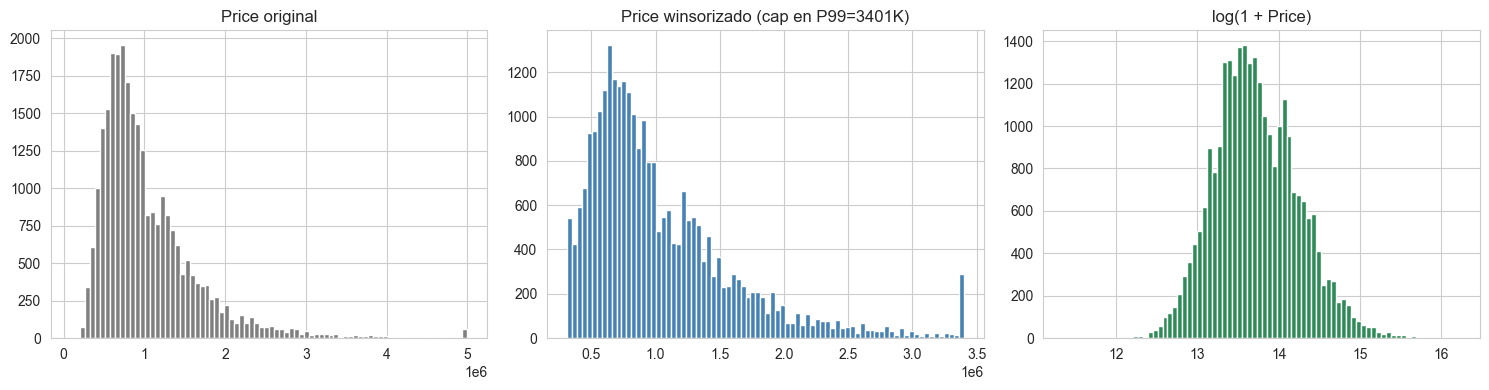

Maximo original:    11,200,000
Maximo winsorizado: 3,400,540


In [18]:
# Winsorizar al percentil 1 y 99
p1  = df['Price'].quantile(0.01)
p99 = df['Price'].quantile(0.99)

df_grupo['Price_winsorized'] = df['Price'].clip(lower=p1, upper=p99)
df_grupo['Price_log']        = np.log1p(df['Price'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['Price'].dropna().clip(0, 5_000_000).hist(
    bins=80, ax=axes[0], color='gray', edgecolor='white')
axes[0].set_title('Price original')

df_grupo['Price_winsorized'].dropna().hist(
    bins=80, ax=axes[1], color='steelblue', edgecolor='white')
p99_k = p99 / 1000
axes[1].set_title(f'Price winsorizado (cap en P99={p99_k:.0f}K)')

df_grupo['Price_log'].dropna().hist(
    bins=80, ax=axes[2], color='seagreen', edgecolor='white')
axes[2].set_title('log(1 + Price)')

plt.tight_layout()
plt.show()

max_orig = df['Price'].max()
max_wins = df_grupo['Price_winsorized'].max()
print(f'Maximo original:    {max_orig:,.0f}')
print(f'Maximo winsorizado: {max_wins:,.0f}')

winsorización
son reales casas con precios muy altos

---
## Parte 4 — Decisión de representación: ¿numérica o categórica?

Algunas variables pueden ser más informativas para el modelo según cómo las representemos.

Precio segun numero de habitaciones:
           media    mediana      n
Rooms                             
1       432889.0   390000.0   1196
2       759484.0   678000.0   6787
3      1028500.0   900000.0  11957
4      1369597.0  1205250.0   5918
5      1818862.0  1550000.0   1209
6      1882613.0  1660000.0    137
7      1791675.0  1350000.0     20
8      1716858.0  1535883.0     14
9      1380000.0  1380000.0      1
10     2018000.0  2115000.0      5
12     2705000.0  2705000.0      2
16     5000000.0  5000000.0      1


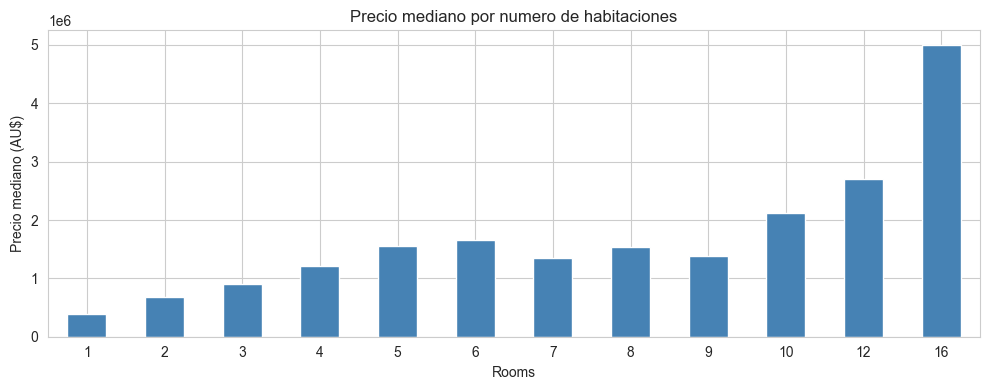

In [19]:
# Precio medio por numero de habitaciones
df_precio = df.dropna(subset=['Price', 'Rooms'])

print('Precio segun numero de habitaciones:')
resumen = df_precio.groupby('Rooms')['Price'].agg(['mean', 'median', 'count'])
resumen.columns = ['media', 'mediana', 'n']
print(resumen.round(0).to_string())

# La relacion es lineal?
plt.figure(figsize=(10, 4))
df_precio.groupby('Rooms')['Price'].median().plot(
    kind='bar', color='steelblue', edgecolor='white')
plt.title('Precio mediano por numero de habitaciones')
plt.xlabel('Rooms')
plt.ylabel('Precio mediano (AU$)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
# Discretizar Rooms en grupos con significado de dominio
df_grupo['Rooms_cat'] = pd.cut(
    df_grupo['Rooms'],
    bins=[0, 2, 4, 6, 100],
    labels=['pequena (1-2)', 'mediana (3-4)', 'grande (5-6)', 'muy grande (7+)']
)

print('Distribucion por categoria:')
print(df_grupo['Rooms_cat'].value_counts().sort_index())

# YearBuilt: ano exacto vs decada de construccion
df_grupo['Decade_built'] = (df_grupo['YearBuilt'] // 10 * 10).astype('Int64')

print()
print('Precio mediano por decada de construccion:')
df_decade = df_grupo.dropna(subset=['Price'])
precio_decada = (
    df_decade.groupby('Decade_built')['Price']
    .median()
    .dropna()
    .apply(lambda x: f'{x/1e3:.0f}K')
    .reset_index()
    .rename(columns={'Price': 'Precio mediano'})
)
print(precio_decada.to_string(index=False))

Distribucion por categoria:
Rooms_cat
pequena (1-2)       9811
mediana (3-4)      23040
grande (5-6)        1941
muy grande (7+)       65
Name: count, dtype: int64

Precio mediano por decada de construccion:
 Decade_built Precio mediano
         1190          1200K
         1820           720K
         1830           855K
         1850          1600K
         1860          2200K
         1870          1750K
         1880          1502K
         1890          1420K
         1900          1315K
         1910          1400K
         1920          1455K
         1930          1400K
         1940          1197K
         1950           980K
         1960           975K
         1970           615K
         1980           760K
         1990           800K
         2000           813K
         2010           735K


---
## Parte 5 — Train/Test Split sin data leakage

Todo lo aprendido (medianas de imputación, límites IQR) debe **calcularse solo en train** y **aplicarse en test**.

In [21]:
cols_modelo = ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize',
               'BuildingArea', 'YearBuilt', 'Propertycount']

df_model = df[cols_modelo + ['Price']].dropna(subset=['Price'])
X = df_model[cols_modelo]
y = df_model['Price']

# Split ANTES de cualquier transformacion
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]:,} filas')
print(f'Test:  {X_test.shape[0]:,} filas')

# Imputar aprendiendo SOLO en train
imputer = SimpleImputer(strategy='median')

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),   # fit + transform en train
    columns=cols_modelo
)
X_test_imp = pd.DataFrame(
    imputer.transform(X_test),         # solo transform en test
    columns=cols_modelo
)

print()
print('Medianas aprendidas en TRAIN (se aplican en test):')
for col, med in zip(cols_modelo, imputer.statistics_):
    print(f'  {col}: {med:.1f}')

Train: 21,797 filas
Test:  5,450 filas

Medianas aprendidas en TRAIN (se aplican en test):
  Rooms: 3.0
  Distance: 10.5
  Bathroom: 1.0
  Car: 2.0
  Landsize: 513.0
  BuildingArea: 132.0
  YearBuilt: 1970.0
  Propertycount: 6567.0


Todas normalizaciones sobre datos de entrenamiento